# LeetCode #374: Guess Number Higher or Lower

https://leetcode.com/problems/guess-number-higher-or-lower/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (linear scan)** | $O(n)$ | $O(1)$ |
| **Binary Search** | $O(\log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (linear scan)
Call `guess(i)` for $i = 1, 2, \ldots$ until it returns 0. With $n$ up to $2^{31} - 1$, this is impractical.

### Optimal: Binary Search ★
The `guess(mid)` API returns -1 (pick is lower), 1 (pick is higher), or 0 (correct). Binary search uses this as a three-way comparator: if -1, narrow to the left half; if 1, narrow to the right half; if 0, return `mid`. Terminates in $O(\log n)$.

**Why this is better than Brute Force:** $O(\log n)$ calls vs $O(n)$ — the API directly tells which half to search.

**Constraints:**
* 1 <= n <= 2^31 - 1
* 1 <= pick <= n

## Solutions

### C#

In [ ]:
/**
 * Forward declaration of guess API.
 * @param  num   your guess
 * @return       -1 if num is higher than the picked number
 *                1 if num is lower than the picked number
 *                0 if num is equal to the picked number
 * int guess(int num);
 */

public class Solution : GuessGame {
    public int GuessNumber(int n) {
        int lo = 1, hi = n;
        while (lo <= hi) {
            // Overflow-safe midpoint
            int mid = lo + (hi - lo) / 2;
            int result = Guess(mid);
            if (result == 0) return mid;
            // API says pick is higher — search right half
            if (result == 1) lo = mid + 1;
            else hi = mid - 1;
        }
        return -1; // unreachable: pick always exists in [1, n]
    }
}

### Python

In [ ]:
# The guess API is already defined for you.
# @param num, your guess
# @return -1 if num is higher than the picked number
#          1 if num is lower than the picked number
#          0 if num is equal to the picked number
# def guess(num: int) -> int:

class Solution:
    def guessNumber(self, n: int) -> int:
        lo, hi = 1, n
        while lo <= hi:
            mid = lo + (hi - lo) // 2
            result = guess(mid)
            if result == 0:
                return mid
            # API says pick is higher — search right half
            if result == 1:
                lo = mid + 1
            else:
                hi = mid - 1
        return -1  # unreachable

### Go

In [ ]:
/**
 * Forward declaration of guess API.
 * @param  num   your guess
 * @return       -1 if num is higher than the picked number
 *                1 if num is lower than the picked number
 *                otherwise return 0
 * func guess(num int) int;
 */

func guessNumber(n int) int {
    lo, hi := 1, n
    for lo <= hi {
        mid := lo + (hi-lo)/2
        result := guess(mid)
        if result == 0 {
            return mid
        }
        // API says pick is higher — search right half
        if result == 1 {
            lo = mid + 1
        } else {
            hi = mid - 1
        }
    }
    return -1 // unreachable
}

### Rust

In [ ]:
/**
 * Your solution calls `guess(num: i32) -> i32`
 *  -1: num > pick (guess too high)
 *   1: num < pick (guess too low)
 *   0: correct
 */

impl Solution {
    unsafe fn guessNumber(n: i32) -> i32 {
        let (mut lo, mut hi) = (1i64, n as i64);
        while lo <= hi {
            let mid = lo + (hi - lo) / 2;
            let result = guess(mid as i32);
            if result == 0 { return mid as i32; }
            // API says pick is higher — search right half
            if result == 1 { lo = mid + 1; } else { hi = mid - 1; }
        }
        -1 // unreachable
    }
}

## Example Scenarios

**1. Common Case**
**Input:** n=10, pick=6
lo=1, hi=10 → mid=5, guess(5)=1 (pick higher) → lo=6. mid=8, guess(8)=-1 (pick lower) → hi=7. mid=6, guess(6)=0 → return 6. Three API calls.

**2. Slightly Complex**
**Input:** n=10, pick=1 (smallest possible)
lo=1, hi=10 → mid=5, -1 → hi=4. mid=2, -1 → hi=1. mid=1, 0 → return 1. Three calls; target is at the leftmost position.

**3. Edge Case: Time Factor**
**Input:** n = 2^31 − 1, pick = 2^31 − 1 (largest possible)
Binary search needs $\lfloor \log_2(2^{31}-1) \rfloor = 30$ calls. Each call returns 1 (pick is higher) until lo==hi==pick. Without overflow-safe midpoint, `(lo + hi) / 2` wraps negative for large n.

**4. Edge Case: Space Factor**
**Input:** n = 2^31 − 1, pick = 1
lo=1, hi=2^31−1 → mid≈10^9, guess=-1 → hi<mid. Narrows rapidly leftward. Only lo, hi, mid used — $O(1)$ space regardless of n. Final answer reached in ~30 steps.

**5. Almost-Impossible but Plausible**
**Input:** n=1, pick=1
lo=1, hi=1 → mid=1, guess(1)=0 → return 1. Single candidate, single API call. The loop runs exactly once.

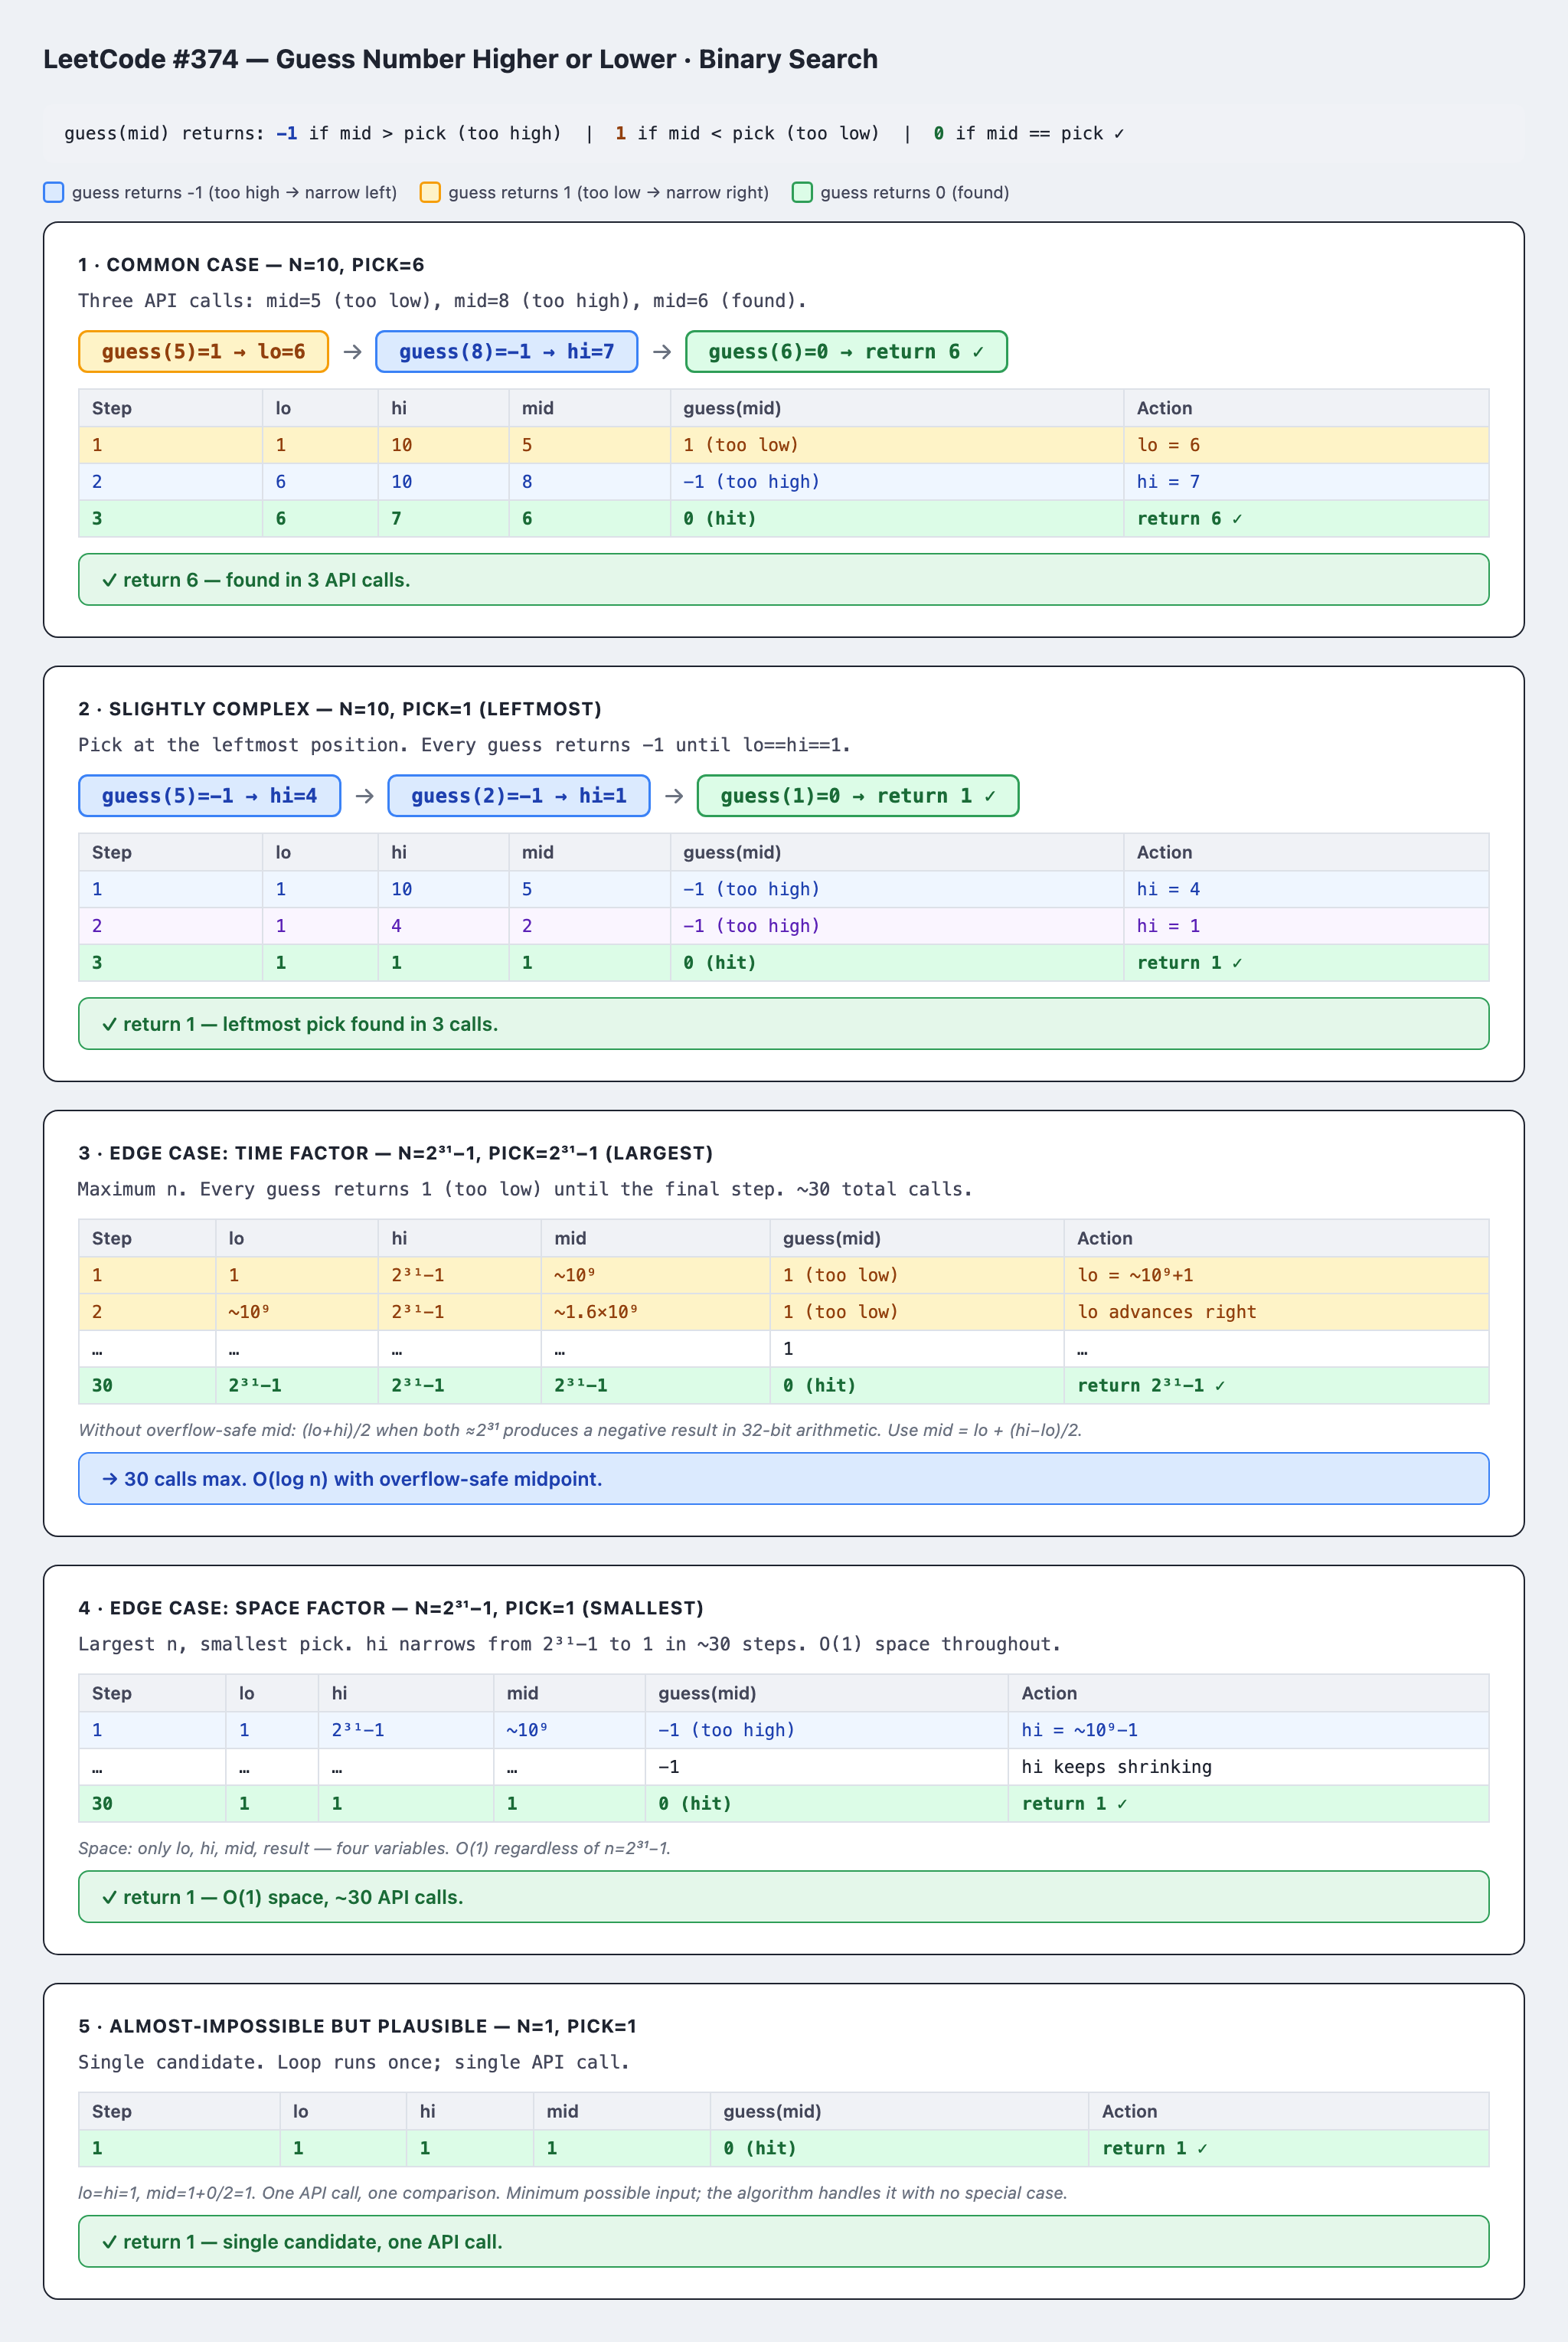